##### Import Libraries

In [140]:
import os
import glob
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
from scipy import stats as st
import time
import pyper as pr 

%matplotlib inline
pd.options.display.max_columns = 100
warnings.filterwarnings("ignore")

from sklearn import preprocessing
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelBinarizer

In [3]:
dataset = []
for root, dirs, files in sorted(os.walk("./AReM/", topdown=False)):
    for name in sorted(files):
        print(os.path.join(root, name))
        df = pd.read_csv(os.path.join(root, name),skiprows = 4)
        dataset.append(df)

./AReM/bending1/dataset1.csv
./AReM/bending1/dataset2.csv
./AReM/bending1/dataset3.csv
./AReM/bending1/dataset4.csv
./AReM/bending1/dataset5.csv
./AReM/bending1/dataset6.csv
./AReM/bending1/dataset7.csv
./AReM/bending2/dataset1.csv
./AReM/bending2/dataset2.csv
./AReM/bending2/dataset3.csv
./AReM/bending2/dataset4.csv
./AReM/bending2/dataset5.csv
./AReM/bending2/dataset6.csv
./AReM/cycling/dataset1.csv
./AReM/cycling/dataset10.csv
./AReM/cycling/dataset11.csv
./AReM/cycling/dataset12.csv
./AReM/cycling/dataset13.csv
./AReM/cycling/dataset14.csv
./AReM/cycling/dataset15.csv
./AReM/cycling/dataset2.csv
./AReM/cycling/dataset3.csv
./AReM/cycling/dataset4.csv
./AReM/cycling/dataset5.csv
./AReM/cycling/dataset6.csv
./AReM/cycling/dataset7.csv
./AReM/cycling/dataset8.csv
./AReM/cycling/dataset9.csv
./AReM/lying/dataset1.csv
./AReM/lying/dataset10.csv
./AReM/lying/dataset11.csv
./AReM/lying/dataset12.csv
./AReM/lying/dataset13.csv
./AReM/lying/dataset14.csv
./AReM/lying/dataset15.csv
./AReM/ly

In [4]:
training_dataset = []
for root, dirs, files in sorted(os.walk("./training", topdown=False)):
    for name in sorted(files):
        print(os.path.join(root, name))
        df = pd.read_csv(os.path.join(root, name),skiprows = 4)
        training_dataset.append(df)
        
testing_dataset = []
for root, dirs, files in sorted(os.walk("./testing", topdown=False)):
    for name in sorted(files):
        print(os.path.join(root, name))
        df = pd.read_csv(os.path.join(root, name),skiprows = 4)
        testing_dataset.append(df)        

./training/bending1/dataset3.csv
./training/bending1/dataset4.csv
./training/bending1/dataset5.csv
./training/bending1/dataset6.csv
./training/bending1/dataset7.csv
./training/bending2/dataset3.csv
./training/bending2/dataset4.csv
./training/bending2/dataset5.csv
./training/bending2/dataset6.csv
./training/cycling/dataset10.csv
./training/cycling/dataset11.csv
./training/cycling/dataset12.csv
./training/cycling/dataset13.csv
./training/cycling/dataset14.csv
./training/cycling/dataset15.csv
./training/cycling/dataset4.csv
./training/cycling/dataset5.csv
./training/cycling/dataset6.csv
./training/cycling/dataset7.csv
./training/cycling/dataset8.csv
./training/cycling/dataset9.csv
./training/lying/dataset10.csv
./training/lying/dataset11.csv
./training/lying/dataset12.csv
./training/lying/dataset13.csv
./training/lying/dataset14.csv
./training/lying/dataset15.csv
./training/lying/dataset4.csv
./training/lying/dataset5.csv
./training/lying/dataset6.csv
./training/lying/dataset7.csv
./train

In [5]:
len(dataset), len(training_dataset), len(testing_dataset)

(88, 69, 19)

### Q1.)(c) Feature Extraction

#### Q1.)(c)(i) Research what types of time-domain features are usually used in time series classification and list them (examples are minimum, maximum, mean, etc).

##### Answer -
##### 1. Mean
##### 2. Median
##### 3. First quartile
##### 4. Third quartile
##### 5. Maximum
##### 6. Minimum
##### 7. Standard Deviation
##### 8. Skewness
##### 9. Kurtosis
##### 10. Root mean square
##### 11. Variance

#### Q1.)(c)(ii) Extract the time-domain features minimum, maximum, mean, median, standard deviation, first quartile, and third quartile for all of the 6 time series in each instance. You are free to normalize/standardize features or use them directly. 

In [6]:
time_series_features = pd.DataFrame()
dataset = sorted(glob.glob("./AReM/*"))
count = 0 
orig_cols = ['avg_rss12','var_rss12','avg_rss13','var_rss13','avg_rss23','var_rss23']
for d in dataset:
    instances = sorted(os.listdir(d+'/'))
    for inst in instances:
        df = pd.read_csv(d+'/'+inst,skiprows = 4)
        # normalize features y = ((x-min)/(max-min))
        feat = df.loc[:,df.columns != '# Columns: time']
        x = feat.values
        min_max_scaler = preprocessing.MinMaxScaler()
        x_scaled = min_max_scaler.fit_transform(x)
        feat = pd.DataFrame(x_scaled)        
        feat.columns = orig_cols
        tf_feat = feat.describe()[1:].transpose()
        time_series_features = time_series_features.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)
        count += 1
        del df, feat, tf_feat
print("Number of instances :- ",count)
print("Dimensions of the feature matrix :- ",time_series_features.shape)

Number of instances :-  88
Dimensions of the feature matrix :-  (88, 42)


In [7]:
# Column names for the features
cols = []
col_names = ['mean','std','min','Q1','median','Q3','max']
for i in range(1,7):
    for j in col_names:
        cols.append(j+"_"+str(i))
time_series_features.columns = cols
time_series_features.head(10)

,mean_1,std_1,min_1,Q1_1,median_1,Q3_1,max_1,mean_2,std_2,min_2,Q1_2,median_2,Q3_2,max_2,mean_3,std_3,min_3,Q1_3,median_3,Q3_3,max_3,mean_4,std_4,min_4,Q1_4,median_4,Q3_4,max_4,mean_5,std_5,min_5,Q1_5,median_5,Q3_5,max_5,mean_6,std_6,min_6,Q1_6,median_6,Q3_6,max_6
0,0.435457,0.190576,0.0,0.258065,0.419355,0.612903,1.0,0.275849,0.248158,0.0,0.000000,0.330769,0.384615,1.0,0.589841,0.175018,0.0,0.470588,0.598039,0.754902,1.0,0.115151,0.133563,0.0,0.000000,0.069156,0.154910,1.0,0.641936,0.198950,0.0,0.522727,0.704545,0.795455,1.0,0.297179,0.303602,0.0,0.000000,0.223958,0.677083,1.0
1,0.627485,0.187164,0.0,0.521512,0.586701,0.739244,1.0,0.305277,0.237015,0.0,0.000000,0.385246,0.409836,1.0,0.658072,0.141590,0.0,0.618182,0.690909,0.736364,1.0,0.152159,0.181816,0.0,0.000000,0.086806,0.198785,1.0,0.494421,0.184234,0.0,0.399815,0.492151,0.630656,1.0,0.183628,0.193251,0.0,0.000000,0.138264,0.418006,1.0
2,0.722137,0.125713,0.0,0.645161,0.752419,0.806452,1.0,0.250735,0.199230,0.0,0.000000,0.276471,0.294118,1.0,0.671929,0.130363,0.0,0.569892,0.709677,0.752688,1.0,0.112007,0.124022,0.0,0.000000,0.096847,0.186937,1.0,0.693522,0.210485,0.0,0.669737,0.736842,0.789474,1.0,0.275582,0.286875,0.0,0.000000,0.240223,0.525140,1.0
3,0.622360,0.248859,0.0,0.416949,0.711864,0.813559,1.0,0.232014,0.210287,0.0,0.000000,0.166667,0.373333,1.0,0.636448,0.177231,0.0,0.558140,0.674419,0.738256,1.0,0.192217,0.185190,0.0,0.083495,0.161165,0.252427,1.0,0.722759,0.206184,0.0,0.560123,0.803428,0.874665,1.0,0.281432,0.240512,0.0,0.000000,0.229358,0.458716,1.0
4,0.680632,0.175960,0.0,0.653333,0.686275,0.764706,1.0,0.189392,0.143275,0.0,0.151943,0.176678,0.250883,1.0,0.633923,0.161866,0.0,0.534653,0.638614,0.754950,1.0,0.131133,0.144673,0.0,0.066978,0.077882,0.174455,1.0,0.447367,0.174333,0.0,0.346168,0.457701,0.548084,1.0,0.214129,0.217410,0.0,0.000000,0.240223,0.279330,1.0
5,0.586814,0.126009,0.0,0.500000,0.568182,0.727273,1.0,0.239293,0.199726,0.0,0.000000,0.297468,0.316456,1.0,0.472627,0.181065,0.0,0.341176,0.435294,0.589176,1.0,0.084681,0.099278,0.0,0.042871,0.049850,0.111665,1.0,0.589600,0.097602,0.0,0.558824,0.607843,0.627451,1.0,0.129210,0.118352,0.0,0.081749,0.095057,0.165399,1.0
6,0.656947,0.137733,0.0,0.600851,0.702128,0.716596,1.0,0.275417,0.175407,0.0,0.286667,0.313333,0.333333,1.0,0.578656,0.150722,0.0,0.513492,0.594039,0.664519,1.0,0.128889,0.152608,0.0,0.000000,0.090909,0.181818,1.0,0.554776,0.170870,0.0,0.472194,0.532441,0.639547,1.0,0.187606,0.164806,0.0,0.000000,0.165541,0.280405,1.0
7,0.308836,0.097713,0.0,0.272876,0.300654,0.359477,1.0,0.086002,0.121893,0.0,0.000000,0.062591,0.103348,1.0,0.754889,0.169744,0.0,0.710620,0.799447,0.868535,1.0,0.108990,0.137137,0.0,0.000000,0.069527,0.128698,1.0,0.663375,0.191091,0.0,0.508536,0.676668,0.844801,1.0,0.140883,0.139581,0.0,0.086519,0.100604,0.175050,1.0
8,0.642447,0.083826,0.0,0.596491,0.654971,0.701754,1.0,0.057952,0.098866,0.0,0.000000,0.055412,0.064433,1.0,0.485183,0.139137,0.0,0.381818,0.481818,0.545455,1.0,0.135402,0.157020,0.0,0.000000,0.086806,0.163194,1.0,0.533877,0.153141,0.0,0.454545,0.545455,0.628788,1.0,0.165995,0.149755,0.0,0.069527,0.122781,0.192308,1.0
9,0.399524,0.215108,0.0,0.178879,0.413793,0.465517,1.0,0.052134,0.079794,0.0,0.000000,0.043434,0.083081,1.0,0.493509,0.208257,0.0,0.353982,0.504425,0.637168,1.0,0.117418,0.138786,0.0,0.058108,0.067568,0.151351,1.0,0.533764,0.175041,0.0,0.440696,0.507304,0.643478,1.0,0.085381,0.097941,0.0,0.034533,0.060985,0.095518,1.0


#### Q1.)(c)(iii) Estimate the standard deviation of each of the time-domain features you extracted from the data. Then, use Python’s bootstrapped or any other method to build a 90% bootstrap confidence interval for the standard deviation of each feature.

In [8]:
n_iterations = 1000
n_size = int(len(time_series_features) * 0.50)
stats = list()
for i in range(n_iterations):
    boot = resample(time_series_features, replace = True, n_samples = n_size)
    std = np.std(boot,axis = 0)
    stats.append(std)

stats = pd.DataFrame(np.matrix(stats))
stats.columns = [t+'*' for t in time_series_features.columns]
sorted_std = pd.DataFrame(np.sort(stats.values, axis = 0), index = stats.index, columns = stats.columns)
sorted_std

,mean_1*,std_1*,min_1*,Q1_1*,median_1*,Q3_1*,max_1*,mean_2*,std_2*,min_2*,Q1_2*,median_2*,Q3_2*,max_2*,mean_3*,std_3*,min_3*,Q1_3*,median_3*,Q3_3*,max_3*,mean_4*,std_4*,min_4*,Q1_4*,median_4*,Q3_4*,max_4*,mean_5*,std_5*,min_5*,Q1_5*,median_5*,Q3_5*,max_5*,mean_6*,std_6*,min_6*,Q1_6*,median_6*,Q3_6*,max_6*
0,0.090111,0.028760,0.0,0.118306,0.125381,0.083712,7.669968e-17,0.078173,0.032593,0.0,0.072741,0.095802,0.106087,1.673724e-17,0.068681,0.022061,0.0,0.084005,0.073178,0.073464,0.000000e+00,0.079012,0.020110,0.0,0.068711,0.081073,0.108404,1.673724e-17,0.068101,0.018361,0.0,0.080877,0.080291,0.071150,0.000000e+00,0.071498,0.025643,0.0,0.052413,0.069091,0.098002,0.000000e+00
1,0.093517,0.033253,0.0,0.132979,0.134927,0.098555,8.026899e-17,0.079316,0.033755,0.0,0.076109,0.096697,0.108248,1.673724e-17,0.068992,0.022575,0.0,0.091110,0.075074,0.075674,1.673724e-17,0.079789,0.021030,0.0,0.069357,0.084126,0.109222,1.673724e-17,0.068480,0.019451,0.0,0.081779,0.082304,0.072210,1.673724e-17,0.073021,0.025737,0.0,0.053073,0.069330,0.106448,0.000000e+00
2,0.105960,0.034387,0.0,0.137259,0.137284,0.099974,9.901886e-17,0.089534,0.034626,0.0,0.077224,0.101002,0.117749,1.673724e-17,0.069257,0.023209,0.0,0.091598,0.077862,0.075724,1.673724e-17,0.080388,0.021057,0.0,0.071284,0.086790,0.109496,1.673724e-17,0.069247,0.020887,0.0,0.083932,0.084118,0.073866,1.673724e-17,0.073690,0.025906,0.0,0.055391,0.071281,0.106516,0.000000e+00
3,0.109390,0.034560,0.0,0.139085,0.139866,0.106617,9.901886e-17,0.090232,0.036225,0.0,0.077483,0.102265,0.119978,1.673724e-17,0.069364,0.023585,0.0,0.093738,0.081406,0.075799,1.673724e-17,0.083095,0.021097,0.0,0.073034,0.087046,0.113550,2.367003e-17,0.069320,0.021081,0.0,0.085219,0.084665,0.074297,1.673724e-17,0.075209,0.026263,0.0,0.055508,0.071828,0.106921,0.000000e+00
4,0.110229,0.034721,0.0,0.139512,0.145394,0.111570,9.901886e-17,0.092265,0.036298,0.0,0.078569,0.102511,0.120860,1.673724e-17,0.070312,0.023801,0.0,0.094952,0.083601,0.075956,2.367003e-17,0.085818,0.021636,0.0,0.075141,0.088987,0.114670,2.367003e-17,0.071282,0.021106,0.0,0.085302,0.085944,0.074343,2.367003e-17,0.075765,0.026431,0.0,0.055781,0.071865,0.106960,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.220506,0.072140,0.0,0.260284,0.257523,0.256366,3.117803e-16,0.179730,0.077178,0.0,0.233320,0.231490,0.233199,5.797951e-17,0.126471,0.047415,0.0,0.173436,0.140380,0.127034,1.031753e-16,0.117558,0.034098,0.0,0.101394,0.121423,0.157859,6.482306e-17,0.138047,0.045953,0.0,0.172041,0.166489,0.137428,1.097534e-16,0.105461,0.053206,0.0,0.087094,0.103776,0.155341,4.099770e-17
996,0.221266,0.072992,0.0,0.260530,0.264561,0.257351,3.153538e-16,0.179851,0.078169,0.0,0.234275,0.232082,0.234838,5.797951e-17,0.126812,0.047749,0.0,0.173842,0.140563,0.127151,1.045240e-16,0.117925,0.034154,0.0,0.101442,0.121568,0.158097,6.482306e-17,0.138260,0.046026,0.0,0.173192,0.168642,0.140213,1.110223e-16,0.106308,0.054196,0.0,0.087773,0.104005,0.156161,4.099770e-17
997,0.221431,0.073073,0.0,0.264238,0.264657,0.257716,3.355807e-16,0.180145,0.078335,0.0,0.236889,0.234769,0.240575,5.797951e-17,0.129192,0.049597,0.0,0.175726,0.141357,0.127494,1.058556e-16,0.118047,0.034253,0.0,0.101935,0.121972,0.158247,6.482306e-17,0.142292,0.046778,0.0,0.173762,0.176451,0.141365,1.135175e-16,0.106854,0.054209,0.0,0.088344,0.105493,0.156444,4.428258e-17
998,0.222685,0.074316,0.0,0.279932,0.265832,0.257910,3.616949e-16,0.182752,0.078385,0.0,0.241167,0.236452,0.247592,5.797951e-17,0.129319,0.049831,0.0,0.177041,0.141435,0.127727,1.071706e-16,0.118320,0.034375,0.0,0.103322,0.122424,0.158432,6.482306e-17,0.143142,0.048097,0.0,0.176516,0.178278,0.143160,1.135175e-16,0.107719,0.054961,0.0,0.089869,0.105752,0.156875,4.428258e-17


##### Answer - Confidence interval is [stat49 - stat949] 

#### Q1.)(c)(iv) Use your judgement to select the three most important time-domain features (one option may be min, mean, and max)

##### Answer - Important time-domain features are mean, median and standard deviation 

### Q1(d) Binary Classification using Logistic Regression

#### Q1(d)(i). Assume that you want to use the training set to classify bending from other activities, i.e. you have a binary classification problem. Depict scatter plots of the features you specified in 1(c)iv extracted from time series 1, 2, and 6 of each instance, and use color to distinguish bending vs. other activities. 

In [9]:
classify1 = time_series_features[['mean_1','std_1','median_1','mean_2','std_2','median_2','mean_6','std_6','median_6']]
classify1['is_bending'] = 0
classify1.iloc[0:13]['is_bending'] = 1
classify1.iloc[13:0]['is_bending'] = 0
classify1

,mean_1,std_1,median_1,mean_2,std_2,median_2,mean_6,std_6,median_6,is_bending
0,0.435457,0.190576,0.419355,0.275849,0.248158,0.330769,0.297179,0.303602,0.223958,1
1,0.627485,0.187164,0.586701,0.305277,0.237015,0.385246,0.183628,0.193251,0.138264,1
2,0.722137,0.125713,0.752419,0.250735,0.199230,0.276471,0.275582,0.286875,0.240223,1
3,0.622360,0.248859,0.711864,0.232014,0.210287,0.166667,0.281432,0.240512,0.229358,1
4,0.680632,0.175960,0.686275,0.189392,0.143275,0.176678,0.214129,0.217410,0.240223,1
...,...,...,...,...,...,...,...,...,...,...
83,0.549542,0.185969,0.570196,0.333107,0.179653,0.307571,0.350189,0.175456,0.348243,0
84,0.455451,0.157490,0.474576,0.337080,0.191257,0.314906,0.321256,0.166593,0.295299,0
85,0.545434,0.168670,0.559646,0.352320,0.205824,0.312500,0.407189,0.201909,0.372035,0
86,0.593358,0.172567,0.612509,0.286196,0.165161,0.261874,0.371280,0.189635,0.340293,0


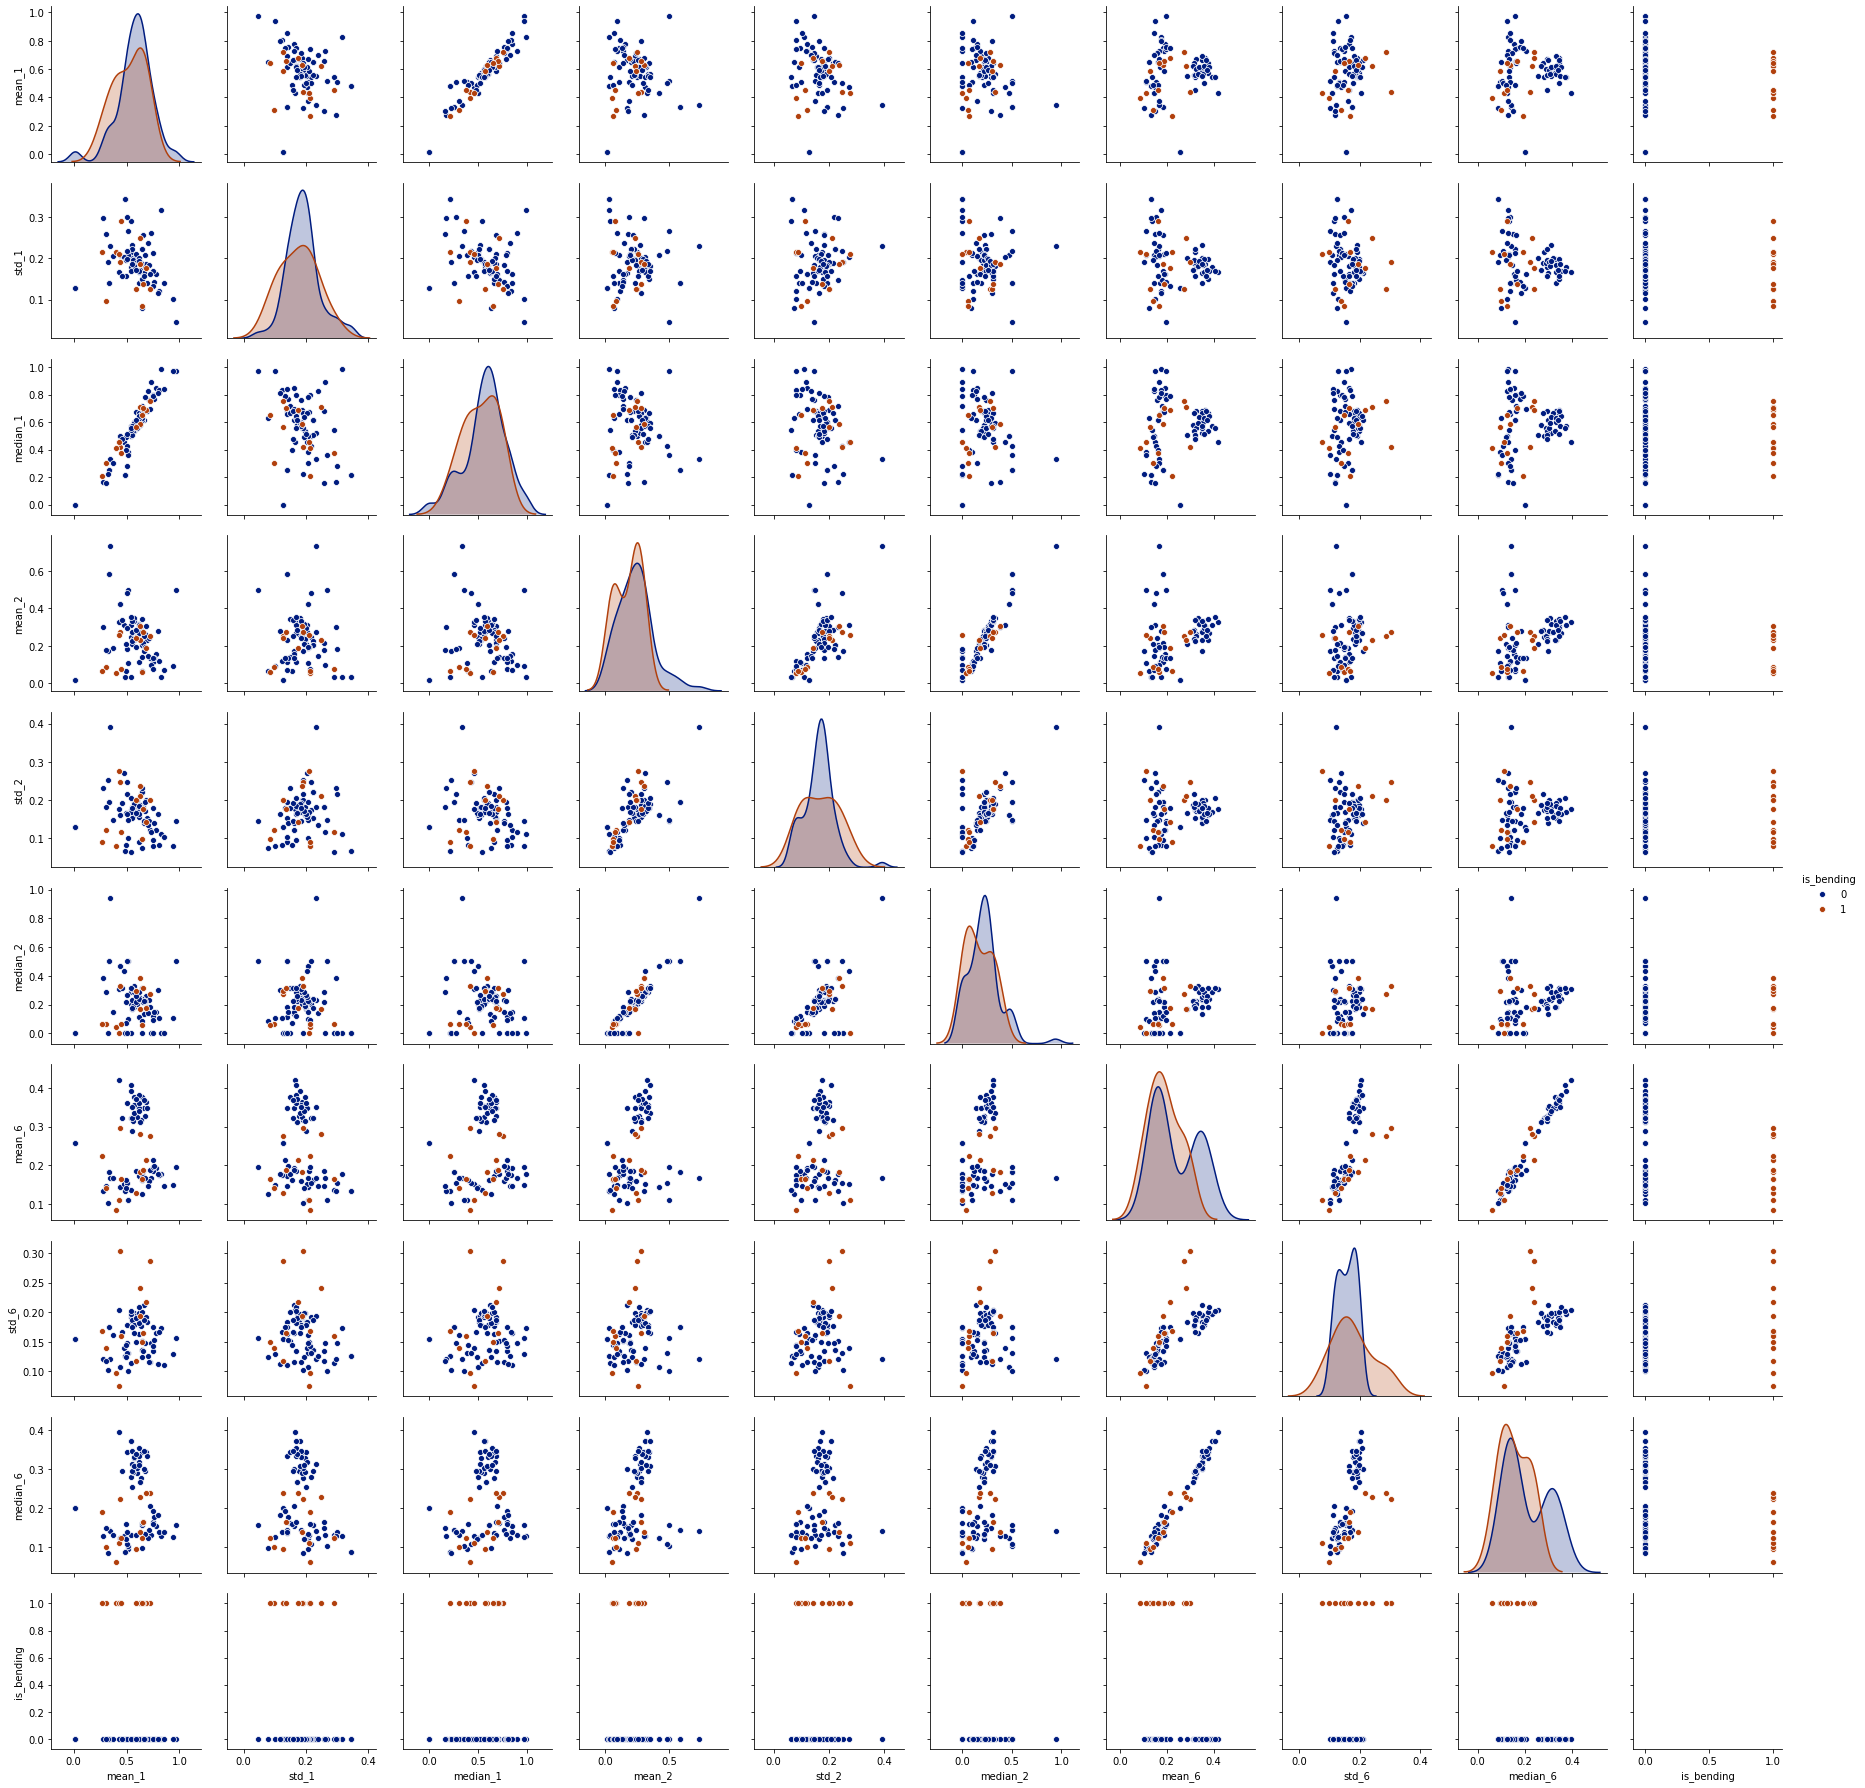

In [10]:
sns.pairplot(classify1, hue = 'is_bending', palette = "dark", dropna = True) 

#### Q1(d)(ii) Break each time series in your training set into two (approximately) equal length time series. Now instead of 6 time series for each of the training instances, you have 12 time series for each training instance. Repeat the experiment in 1(d)i, i.e depict scatter plots of the features extracted from both parts of the time series 1,2, and 12. Do you see any considerable difference in the results with those of 1(d)i?

In [11]:
training_folder = sorted(glob.glob("./training"))
training_time_domain_features = pd.DataFrame()
for t in training_folder:
    activities = sorted(os.listdir(t+'/'))
    for act in activities:
        instances = sorted(os.listdir(t+'/'+act+'/'))
        for inst in instances:
            feat = pd.read_csv(t+'/'+act+'/'+inst,skiprows = 4)
            feat = feat.loc[:,feat.columns != '# Columns: time']
            new_feat = pd.DataFrame()
            for idx, f in enumerate(feat.columns):
                new_feat = pd.concat([pd.DataFrame(feat.iloc[0:int(feat.shape[0]/2)].values),pd.DataFrame(feat.iloc[int(feat.shape[0]/2):].values)],axis = 1)
            new_feat.columns = [f for f in feat.columns]+[f+'_1' for f in feat.columns]
            new_cols = new_feat.columns
            x = new_feat.values
            min_max_scaler = preprocessing.MinMaxScaler()
            x_scaled = min_max_scaler.fit_transform(x)
            new_feat = pd.DataFrame(x_scaled)
            new_feat.columns = new_cols
            #print(new_feat.shape)
            training_time_domain_features = training_time_domain_features.append(
                pd.Series(new_feat.describe().transpose()[['mean','std','50%']].values.flatten()),\
                                                               ignore_index = True)
print("Shape of training domain features :- ",training_time_domain_features.shape)

Shape of training domain features :-  (69, 36)


In [12]:
# Column names for the features
train_cols = []
col_names = ['mean1','std1','median1','mean2','std2','median2']
for i in range(1,7):
    for j in col_names:
        train_cols.append(j+"_"+str(i))
training_time_domain_features.columns = train_cols
training_time_domain_features.head(10)

,mean1_1,std1_1,median1_1,mean2_1,std2_1,median2_1,mean1_2,std1_2,median1_2,mean2_2,std2_2,median2_2,mean1_3,std1_3,median1_3,mean2_3,std2_3,median2_3,mean1_4,std1_4,median1_4,mean2_4,std2_4,median2_4,mean1_5,std1_5,median1_5,mean2_5,std2_5,median2_5,mean1_6,std1_6,median1_6,mean2_6,std2_6,median2_6
0,0.755717,0.155697,0.800000,0.254028,0.219694,0.313333,0.589786,0.160708,0.650000,0.180094,0.181905,0.156934,0.740417,0.154791,0.735294,0.334218,0.294221,0.279330,0.713858,0.125578,0.685484,0.277328,0.201380,0.294118,0.630018,0.140649,0.607527,0.112875,0.134997,0.096847,0.636041,0.248507,0.756757,0.258889,0.319019,0.000000
1,0.680634,0.248097,0.803571,0.224431,0.211428,0.161667,0.639013,0.164382,0.671053,0.169401,0.161280,0.148847,0.665672,0.208347,0.662879,0.418927,0.362446,0.500000,0.621596,0.272114,0.692308,0.251326,0.219551,0.174825,0.613301,0.201626,0.650602,0.227532,0.209560,0.168932,0.592741,0.203250,0.562973,0.268846,0.225630,0.215596
2,0.676173,0.244600,0.731765,0.220171,0.173002,0.176678,0.636889,0.202097,0.653465,0.173689,0.182372,0.128505,0.463365,0.195329,0.457701,0.234125,0.229721,0.240223,0.562198,0.134824,0.509050,0.400781,0.243795,0.446429,0.559275,0.236987,0.565217,0.241986,0.194167,0.200000,0.363583,0.206265,0.375000,0.231667,0.242096,0.286667
3,0.568560,0.151093,0.666667,0.192340,0.241615,0.000000,0.553936,0.193260,0.566265,0.111964,0.113817,0.082752,0.562498,0.126276,0.574468,0.155022,0.136505,0.134981,0.609776,0.111452,0.596842,0.320332,0.165039,0.316456,0.462429,0.139339,0.485714,0.110501,0.140209,0.082534,0.825049,0.104540,0.847222,0.133959,0.116612,0.123153
4,0.818272,0.153899,0.845138,0.291282,0.218796,0.361538,0.555184,0.155362,0.576579,0.128232,0.161034,0.090909,0.566192,0.219959,0.519310,0.230208,0.213529,0.206140,0.698046,0.150745,0.702128,0.298389,0.156995,0.333333,0.615057,0.174819,0.633333,0.188132,0.209160,0.132022,0.663840,0.157510,0.653061,0.197889,0.164837,0.168919
5,0.379806,0.301499,0.176724,0.059381,0.094558,0.047475,0.479917,0.211211,0.464118,0.123643,0.160081,0.063514,0.598858,0.205057,0.605739,0.113008,0.120435,0.076782,0.684227,0.104633,0.666667,0.237634,0.322637,0.000000,0.530020,0.253914,0.565146,0.167243,0.170826,0.101626,0.684243,0.171114,0.685714,0.130572,0.127643,0.117940
6,0.428104,0.234491,0.322500,0.298958,0.299197,0.430000,0.486704,0.249103,0.448276,0.164743,0.172728,0.112613,0.560799,0.167616,0.547755,0.113333,0.093612,0.110937,0.620583,0.254027,0.600000,0.245881,0.279988,0.000000,0.678514,0.203003,0.731529,0.143133,0.166814,0.172000,0.491595,0.228197,0.514580,0.451944,0.214806,0.473333
7,0.503204,0.307007,0.395062,0.114790,0.168823,0.099307,0.428180,0.325356,0.424398,0.167278,0.213283,0.106965,0.515056,0.168245,0.510204,0.163416,0.172535,0.121842,0.497503,0.336322,0.392157,0.068327,0.115341,0.067187,0.466069,0.169237,0.444444,0.077288,0.099986,0.043783,0.494882,0.208745,0.424701,0.198737,0.177621,0.155080
8,0.404917,0.226544,0.244444,0.082837,0.111741,0.073668,0.564111,0.219877,0.551538,0.165139,0.174217,0.133459,0.444039,0.229162,0.452517,0.211518,0.172777,0.176221,0.375734,0.179309,0.323125,0.129549,0.148590,0.197248,0.682145,0.171499,0.722941,0.149231,0.169990,0.091262,0.597605,0.201915,0.657534,0.243894,0.170361,0.203252
9,0.495894,0.256404,0.441731,0.262007,0.177817,0.215855,0.464361,0.169574,0.458333,0.373576,0.212058,0.344415,0.596766,0.177835,0.609375,0.312152,0.188240,0.270286,0.547937,0.228972,0.506944,0.258913,0.186774,0.188620,0.547168,0.190175,0.540869,0.288855,0.162065,0.261074,0.476963,0.221043,0.493782,0.351423,0.202492,0.318131


In [13]:
classify2 = training_time_domain_features[['mean1_1','std1_1','median1_1','mean2_1','std2_1','median2_1','mean2_6','std2_6','median2_6']]
classify2['is_bending'] = 0
classify2.iloc[0:9]['is_bending'] = 1
classify2.iloc[9:]['is_bending'] = 0
classify2

,mean1_1,std1_1,median1_1,mean2_1,std2_1,median2_1,mean2_6,std2_6,median2_6,is_bending
0,0.755717,0.155697,0.800000,0.254028,0.219694,0.313333,0.258889,0.319019,0.000000,1
1,0.680634,0.248097,0.803571,0.224431,0.211428,0.161667,0.268846,0.225630,0.215596,1
2,0.676173,0.244600,0.731765,0.220171,0.173002,0.176678,0.231667,0.242096,0.286667,1
3,0.568560,0.151093,0.666667,0.192340,0.241615,0.000000,0.133959,0.116612,0.123153,1
4,0.818272,0.153899,0.845138,0.291282,0.218796,0.361538,0.197889,0.164837,0.168919,1
...,...,...,...,...,...,...,...,...,...,...
64,0.533851,0.199958,0.556401,0.331858,0.183907,0.307571,0.365304,0.175504,0.356763,0
65,0.547664,0.176943,0.579230,0.345400,0.191463,0.330057,0.315957,0.163107,0.302155,0
66,0.583294,0.192867,0.601612,0.348248,0.197195,0.313505,0.408833,0.208563,0.368914,0
67,0.643025,0.189680,0.678613,0.343922,0.202959,0.304523,0.351190,0.203953,0.315412,0


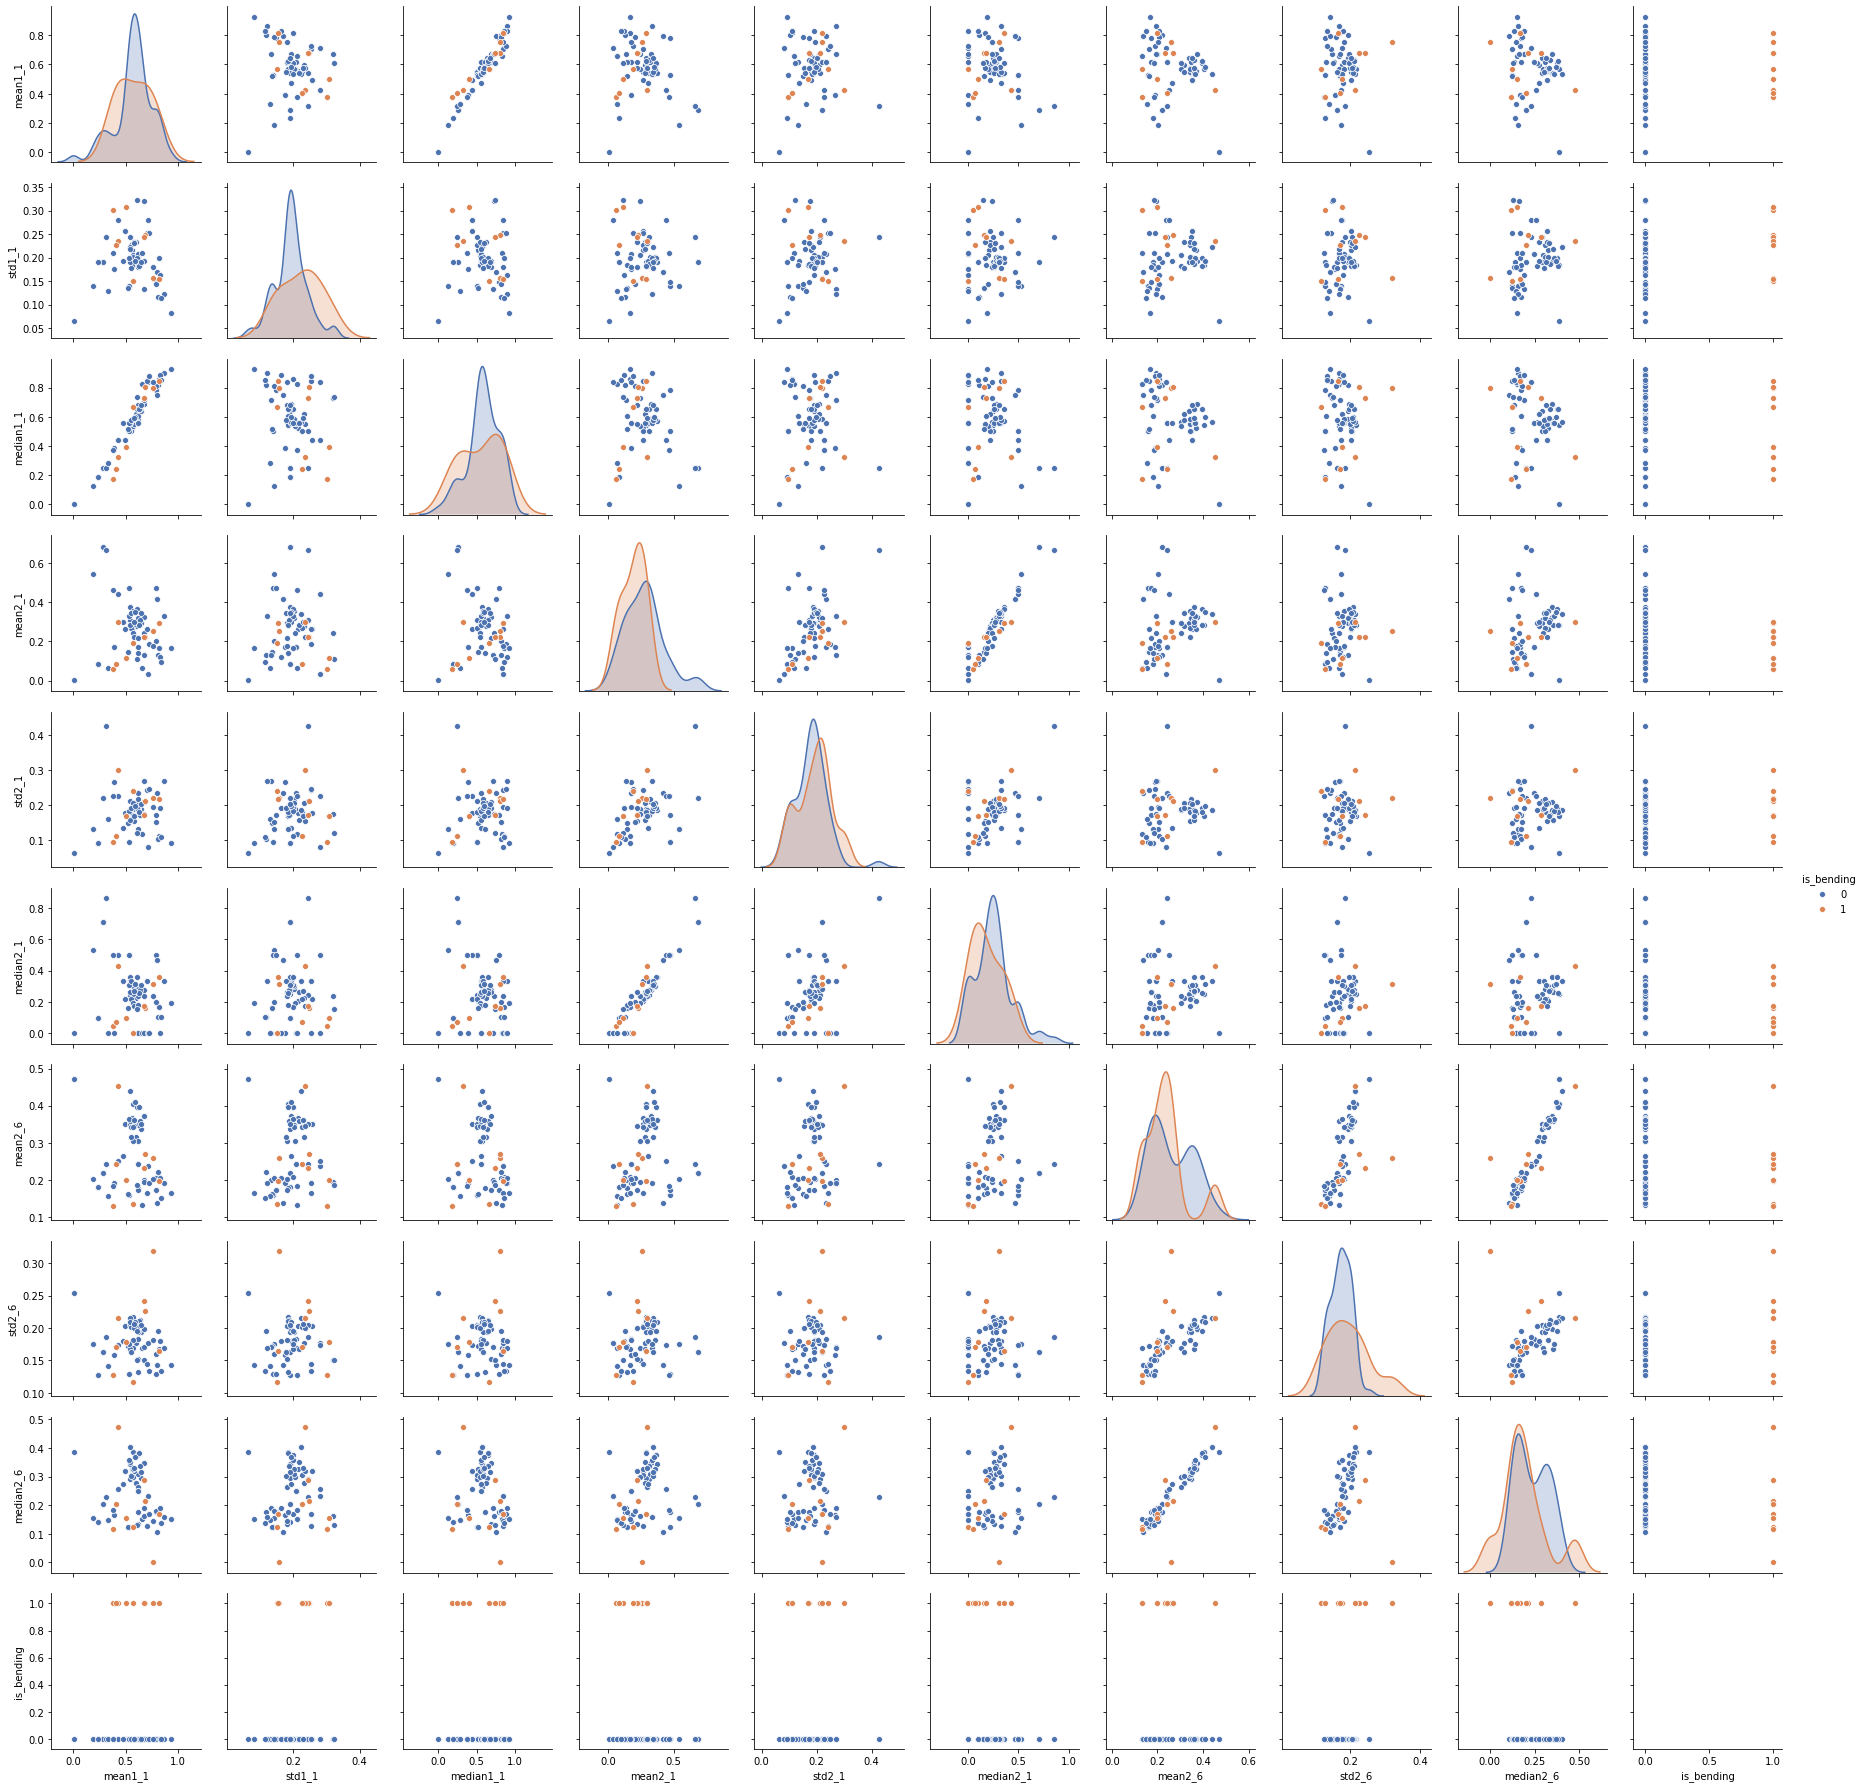

In [14]:
sns.pairplot(classify2, hue = 'is_bending', palette = "deep", dropna = True) 

#### Qd(iii) Break each time series in your training set into l ∈ {1, 2, . . . , 20} time series of approximately equal length and use logistic regression 5 to solve the binary classification problem, using time-domain features. Remember that breaking each of the time series does not change the number of instances. It only changes the number of features for each instance. Calculate the p-values for your logistic regression parameters in each model corresponding to each value of l and refit a logistic regression model using your pruned set of features. 6 Alternatively, you can use backward selection using sklearn.feature selection or glm in R. Use 5-fold cross-validation to determine the best value of the pair (l, p), where p is the number of features used in recursive feature elimination. Explain what the right way and the wrong way are to perform cross-validation in this problem. 7 Obviously, use the right way! Also, you may encounter the problem of class imbalance, which may make some of your folds not having any instances of the rare class. In such a case, you can use stratified cross validation. Research what it means and use it if needed.

In [15]:
split_range = range(1,21)
def split_df(df, nrows, chunk_size):
    indices = list(range(1 * chunk_size, (nrows // chunk_size) * chunk_size, chunk_size))
    chunks = np.split(df, indices)
    return chunks

In [45]:
# BUILD 20 DATAFRAMES FROM TRAINING DATASET
nrows = 480
models_notnormalized = []

t = time.time()
for l in split_range:
    new_features = pd.DataFrame() 
    for feat in training_dataset:
        feat = feat.loc[:,feat.columns != '# Columns: time']

        # break the dataset
        new_pd = pd.DataFrame()
        chunk_size = int(nrows/l)
        chunks = split_df(feat, nrows, chunk_size)
        for c in chunks:
            new_pd = pd.concat([new_pd,c.reset_index(drop = True)],axis = 1)

        # time-domain features
        tf_feat = new_pd.describe()[1:].transpose()
        new_features = new_features.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)
    models_notnormalized.append(new_features)
    print(l," ",new_features.shape)
print("Time_taken :- ",(time.time()-t)/60," minutes")

1   (69, 42)
2   (69, 84)
3   (69, 126)
4   (69, 168)
5   (69, 210)
6   (69, 252)
7   (69, 294)
8   (69, 336)
9   (69, 378)
10   (69, 420)
11   (69, 462)
12   (69, 504)
13   (69, 546)
14   (69, 588)
15   (69, 630)
16   (69, 672)
17   (69, 714)
18   (69, 756)
19   (69, 798)
20   (69, 840)
Time_taken :-  2.6607919613520306  minutes


In [46]:
# CROSS VALIDATION ON TRAINING FEATURES TO SELECT BEST (l,p) PAIR
rfecv_scores = []
num_optimal_features = {}
optimal_features = {}
#logistic_models = []

for l, m in enumerate(models_notnormalized):
# target variable
    m['is_bending'] = 0
    m.iloc[0:9]['is_bending'] = 1
    m.iloc[9:]['is_bending'] = 0    
    features = m.iloc[:,0:(m.shape[1] - 1)]
    target = m.iloc[:,(m.shape[1] - 1)]
    print(m.shape, features.shape, target.shape)

    logreg = LogisticRegression(C=100)
    rfecv = RFECV(estimator = logreg, step = 1, cv = StratifiedKFold(5),scoring = 'accuracy')
    rfecv.fit(features, target)
    print("Optimal number of features : %d" % rfecv.n_features_)
    num_optimal_features[l+1] = rfecv.n_features_
    cols_select_index = [idx for idx, val in enumerate(rfecv.ranking_) if val == 1]
    optimal_features[l+1] = cols_select_index
    scores = rfecv.grid_scores_
    print(len(scores))
    print(max(scores))
    rfecv_scores.append(max(scores))
    print(l+1," Done\n")

(69, 43) (69, 42) (69,)
Optimal number of features : 4
42
0.9857142857142858
1  Done

(69, 85) (69, 84) (69,)
Optimal number of features : 4
84
0.9857142857142858
2  Done

(69, 127) (69, 126) (69,)
Optimal number of features : 4
126
1.0
3  Done

(69, 169) (69, 168) (69,)
Optimal number of features : 4
168
0.9714285714285715
4  Done

(69, 211) (69, 210) (69,)
Optimal number of features : 15
210
0.9857142857142858
5  Done

(69, 253) (69, 252) (69,)
Optimal number of features : 11
252
0.9714285714285715
6  Done

(69, 295) (69, 294) (69,)
Optimal number of features : 10
294
0.9714285714285715
7  Done

(69, 337) (69, 336) (69,)
Optimal number of features : 13
336
0.9714285714285715
8  Done

(69, 379) (69, 378) (69,)
Optimal number of features : 28
378
0.9714285714285715
9  Done

(69, 421) (69, 420) (69,)
Optimal number of features : 22
420
0.9714285714285715
10  Done

(69, 463) (69, 462) (69,)
Optimal number of features : 2
462
0.9714285714285715
11  Done

(69, 505) (69, 504) (69,)
Optimal 

In [47]:
best_l = rfecv_scores.index(max(rfecv_scores))+1
print("Best value of l :- ",best_l,"\nScore at l :- ",max(rfecv_scores))
print("Number of features used in Recursive Feature Elimination :- ",num_optimal_features[best_l])
print("Best (l,p) pair :- ",'('+str(best_l)+','+str(num_optimal_features[best_l])+')')

Best value of l :-  3 
Score at l :-  1.0
Number of features used in Recursive Feature Elimination :-  4
Best (l,p) pair :-  (3,4)


#### Qd(iv) Report the confusion matrix and show the ROC and AUC for your classifier on train data. Report the parameters of your logistic regression β i ’s as well as the p-values associated with them.

(69, 127)
(69, 127)
(69, 126) (69,)
(48, 4) (21, 4) (48,) (21,)
========== Confusion Matrix ==========
[[18  0]
 [ 0  3]]
Area under the curve :-  1.0


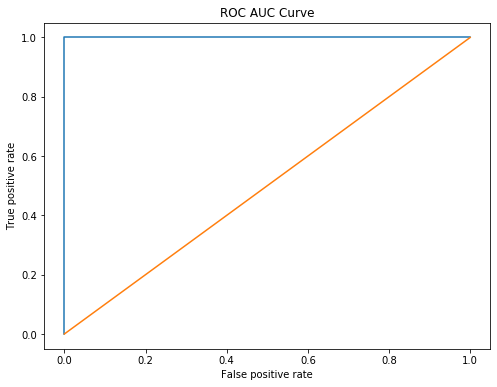

In [54]:
# MODELLING ON BEST L MODEL
model_best_l = models_notnormalized[best_l - 1]
print(model_best_l.shape)
model_best_l['is_bending'] = 0
model_best_l.iloc[0:9]['is_bending'] = 1
model_best_l.iloc[9:]['is_bending'] = 0    
print(model_best_l.shape)
features = model_best_l.iloc[:,0:(model_best_l.shape[1] - 1)]
target = model_best_l.iloc[:,(model_best_l.shape[1] - 1)]
print(features.shape, target.shape)
new_features = features[optimal_features[best_l]]
X_train, X_test, y_train, y_test = train_test_split(new_features, target, test_size = 0.3, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
logreg_l = LogisticRegression(C = 100)
logreg_l.fit(X_train, y_train)
y_pred = logreg_l.predict(X_test)

confusion_matrix_1 = metrics.confusion_matrix(y_test, y_pred)
print("========== Confusion Matrix ==========")
print(confusion_matrix_1)
fpr_1, tpr_1, _ = metrics.roc_curve(y_test, y_pred)
auc_1 = metrics.roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.plot(fpr_1, tpr_1, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc)

#### Model coefficients

In [55]:
logreg_l.coef_

array([[ 1.24752611,  1.56356646, -1.10842036, -0.79436874]])

#### Model p-values

In [56]:
sm_model = sm.Logit(y_train, X_train).fit(maxiter = 10)
sm_model.pvalues

         Current function value: 0.000071
         Iterations: 10


30     0.863963
33     0.791359
47     0.694978
125    0.881120
dtype: float64

#### Qd(v) Test the classifier on the test set. Remember to break the time series in your test set into the same number of time series into which you broke your training set. Remember that the classifier has to be tested using the features extracted from the test set. Compare the accuracy on the test set with the cross-validation accuracy you obtained previously.

(19, 5) (19, 4) (19,)
========== Confusion Matrix ==========
[[15  0]
 [ 0  4]]
Area under the curve :-  1.0


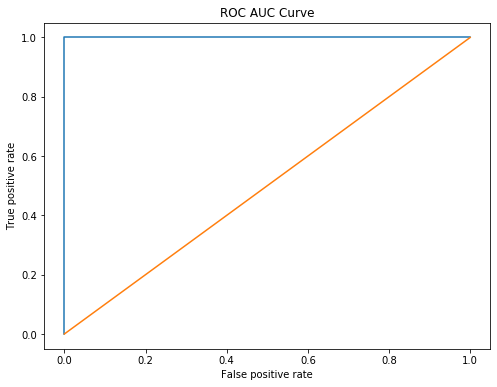

In [67]:
# TESTING BEST L MODEL
nrows = 480

t = time.time()
test_dataframe = pd.DataFrame() 
for feat in testing_dataset:
    feat = feat.loc[:,feat.columns != '# Columns: time']

    # break the dataset
    new_pd = pd.DataFrame()
    chunk_size = int(nrows/best_l)
    chunks = split_df(feat, nrows, chunk_size)
    for c in chunks:
        new_pd = pd.concat([new_pd,c.reset_index(drop = True)],axis = 1)

    # time-domain features
    tf_feat = new_pd.describe()[1:].transpose()
    test_dataframe = test_dataframe.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)

test_dataframe = test_dataframe[optimal_features[best_l]]
test_dataframe["is_bending"] = 0
test_dataframe.iloc[0:4]['is_bending'] = 1
test_dataframe.iloc[4:]['is_bending'] = 0    
features = test_dataframe.iloc[:,0:(test_dataframe.shape[1] - 1)]
target = test_dataframe.iloc[:,(test_dataframe.shape[1] - 1)]
print(test_dataframe.shape, features.shape, target.shape)
test_values = logreg_l.predict(features)

confusion_matrix_2 = metrics.confusion_matrix(target,test_values)
print("========== Confusion Matrix ==========")
print(confusion_matrix_2)
fpr_2, tpr_2, _ = metrics.roc_curve(target,test_values)
auc_2 = metrics.roc_auc_score(target,test_values)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_2)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_2)

#### Qd(vi) Do your classes seem to be well-separated to cause instability in calculating logistic regression parameters?

##### Yes, the FP and FN are zero

#### Qd(vii) From the confusion matrices you obtained, do you see imbalanced classes? If yes, build a logistic regression model based on case-control sampling and adjust its parameters. Report the confusion matrix, ROC, and AUC of the model.

In [23]:
tn, fp, fn, tp = confusion_matrix.ravel()
print("Imbalance percentage :- ", round(((tn+fp)/(tn+fp+fn+tp))*100,2),"%,",\
      round(((tp+fn)/(tn+fp+fn+tp))*100,2),"%")

Imbalance percentage :-  85.71 %, 14.29 %


(18, 127)
(12, 126) (6, 126) (12,) (6,)
========== Confusion Matrix ==========
[[4 0]
 [1 1]]
Area under the curve :-  0.75


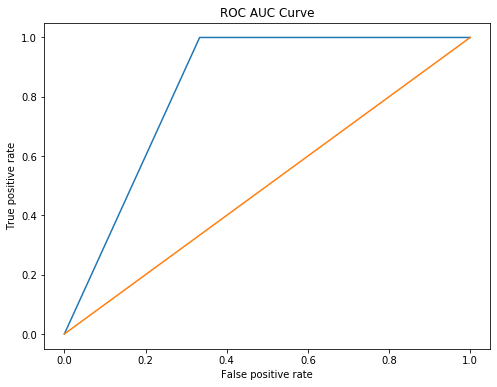

In [90]:
 # Separate majority and minority classes
df_majority = model_best_l[model_best_l['is_bending'] == 0]
df_minority = model_best_l[model_best_l['is_bending'] == 1]
 
# Downsample majority class
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    # sample without replacement
                                 n_samples=9 ,     # to match minority class
                                 random_state=123) # reproducible results
 
# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])
 
# Display new class counts
df_downsampled["is_bending"].value_counts()

print(df_downsampled.shape)

df_downsampled = shuffle(df_downsampled)
features = df_downsampled.iloc[:,0:(df_downsampled.shape[1] - 1)]
target = df_downsampled.iloc[:,(df_downsampled.shape[1] - 1)]
 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 4)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
downsampled_model = LogisticRegression(C = 100)
downsampled_model.fit(X_train, y_train)
y_pred = downsampled_model.predict(X_test)

confusion_matrix_3 = metrics.confusion_matrix(y_test, y_pred)
print("========== Confusion Matrix ==========")
print(confusion_matrix_3)
fpr_3, tpr_3, _ = metrics.roc_curve(y_test, y_pred)
auc_3 = metrics.roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_3)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_3)

#### Q1(e)(i) Repeat 1(d)iii using L 1 -penalized logistic regression,  i.e. instead of using p-values for variable selection, use L 1 regularization. Note that in this problem,you have to cross-validate for both l, the number of time series into which you break each of your instances, and λ, the weight of L 1 penalty in your logistic regression objective function (or C, the budget). Packages usually perform cross-validation for λ automatically. 

In [108]:
nrows = 480
models_normalized = []

t = time.time()
for l in split_range:
    new_features = pd.DataFrame() 
    for feat in training_dataset:
        feat = feat.loc[:,feat.columns != '# Columns: time']
        
        # Normalise original instance
        x = feat.values
        normalized_X = preprocessing.normalize(x)
        feat = pd.DataFrame(normalized_X)
        feat.columns = orig_cols

        # break the dataset
        new_pd = pd.DataFrame()
        chunk_size = int(nrows/l)
        chunks = split_df(feat, nrows, chunk_size)
        for c in chunks:
            new_pd = pd.concat([new_pd,c.reset_index(drop = True)],axis = 1)

        # time-domain features
        tf_feat = new_pd.describe()[1:].transpose()
        new_features = new_features.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)
    models_normalized.append(new_features)
    print(l," ",new_features.shape)
print("Time_taken :- ",(time.time()-t)/60," minutes")

1   (69, 42)
2   (69, 84)
3   (69, 126)
4   (69, 168)
5   (69, 210)
6   (69, 252)
7   (69, 294)
8   (69, 336)
9   (69, 378)
10   (69, 420)
11   (69, 462)
12   (69, 504)
13   (69, 546)
14   (69, 588)
15   (69, 630)
16   (69, 672)
17   (69, 714)
18   (69, 756)
19   (69, 798)
20   (69, 840)
Time_taken :-  2.576238771279653  minutes


In [109]:
grid = {"C":np.logspace(-4,4,7)}
C_values = []
cv_scores = []
l1_logreg_models = []

for l, m in enumerate(models_normalized):
    print(m.shape)
    m['is_bending'] = 0
    m.iloc[0:9]['is_bending'] = 1
    m.iloc[9:]['is_bending'] = 0    
    features = m.iloc[:,0:(m.shape[1] - 1)]
    target = m.iloc[:,(m.shape[1] - 1)]
    print(features.shape, target.shape)
    logreg = LogisticRegression(penalty = 'l1',solver = 'liblinear',random_state=4)
    logreg_cv = GridSearchCV(logreg, grid, cv = StratifiedKFold(5))
    logreg_cv.fit(features,target)
    best_logreg_c = logreg_cv.best_estimator_.get_params()['C']
    C_values.append(best_logreg_c)
    print(l+1, best_logreg_c)
    
    logreg_refit = LogisticRegression(C = best_logreg_c, penalty = 'l1',solver = 'liblinear',random_state=4)
    logreg_refit.fit(features, target)
    l1_logreg_models.append(logreg_refit)
    print(cross_val_score(logreg_refit, features, target, cv = StratifiedKFold(5)).mean())
    cv_scores.append(cross_val_score(logreg_refit, features, target, cv = StratifiedKFold(5)).mean())    

(69, 42)
(69, 42) (69,)
1 21.54434690031882
0.9274725274725275
(69, 84)
(69, 84) (69,)
2 21.54434690031882
0.9703296703296704
(69, 126)
(69, 126) (69,)
3 21.54434690031882
0.9417582417582417
(69, 168)
(69, 168) (69,)
4 10000.0
0.9560439560439562
(69, 210)
(69, 210) (69,)
5 21.54434690031882
0.9274725274725275
(69, 252)
(69, 252) (69,)
6 464.1588833612773
0.956043956043956
(69, 294)
(69, 294) (69,)
7 464.1588833612773
0.9417582417582417
(69, 336)
(69, 336) (69,)
8 464.1588833612773
0.9417582417582417
(69, 378)
(69, 378) (69,)
9 21.54434690031882
0.9274725274725275
(69, 420)
(69, 420) (69,)
10 464.1588833612773
0.9417582417582417
(69, 462)
(69, 462) (69,)
11 464.1588833612773
0.9560439560439562
(69, 504)
(69, 504) (69,)
12 464.1588833612773
0.9703296703296704
(69, 546)
(69, 546) (69,)
13 21.54434690031882
0.9846153846153847
(69, 588)
(69, 588) (69,)
14 464.1588833612773
0.956043956043956
(69, 630)
(69, 630) (69,)
15 464.1588833612773
0.956043956043956
(69, 672)
(69, 672) (69,)
16 464.158

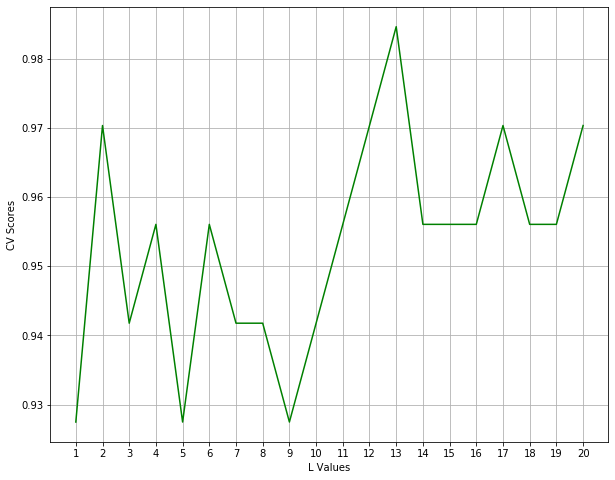

In [110]:
# Plot of CV Scores
plt.figure(figsize=(10,8))
plt.plot(list(split_range),cv_scores,color='green',label='CV scores')
plt.xticks(np.arange(1,21))
plt.xlabel("L Values")
plt.ylabel("CV Scores")
plt.grid()

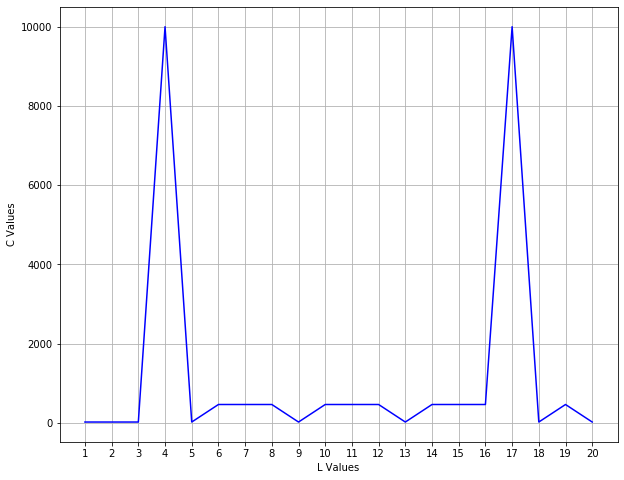

In [111]:
# Plot of C Values
plt.figure(figsize=(10,8))
plt.plot(list(split_range),C_values,color='blue',label='CV scores')
plt.xticks(np.arange(1,21))
plt.xlabel("L Values")
plt.ylabel("C Values")
plt.grid()

13 21.54434690031882 0.9846153846153847
(69, 547)
(69, 546) (69,)
(48, 546) (21, 546) (48,) (21,)
========== Confusion Matrix ==========
[[18  0]
 [ 0  3]]
Area under the curve :-  1.0


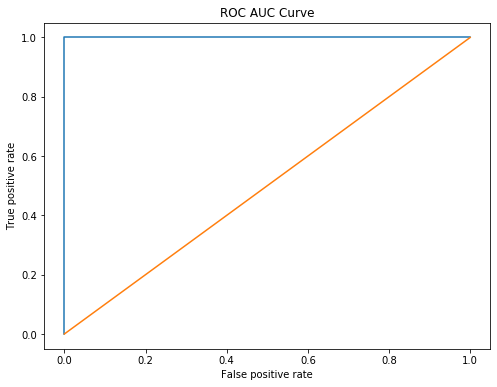

In [112]:
# TRAINING DATASET ON BEST L
best_l_l1 = cv_scores.index(max(cv_scores))+1
print(best_l_l1, C_values[best_l_l1-1], cv_scores[best_l_l1-1])
best_l1_model = l1_logreg_models[best_l_l1-1]

model_best_l1 = models_normalized[best_l_l1 - 1]
print(model_best_l1.shape)
model_best_l1['is_bending'] = 0
model_best_l1.iloc[0:9]['is_bending'] = 1
model_best_l1.iloc[9:]['is_bending'] = 0    

features = model_best_l1.iloc[:,0:(model_best_l1.shape[1] - 1)]
target = model_best_l1.iloc[:,(model_best_l1.shape[1] - 1)]
print(features.shape, target.shape)
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_pred = best_l1_model.predict(X_test)

confusion_matrix_4 = metrics.confusion_matrix(y_test, y_pred)
print("========== Confusion Matrix ==========")
print(confusion_matrix_4)
fpr_4, tpr_4, _ = metrics.roc_curve(y_test, y_pred)
auc_4 = metrics.roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8,6))
plt.plot(fpr_4, tpr_4, label='ROC curve (area = %0.2f)' % auc_4)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_4)

(19, 547) (19, 546) (19,)
========== Confusion Matrix ==========
[[15  0]
 [ 1  3]]
Area under the curve :-  0.875


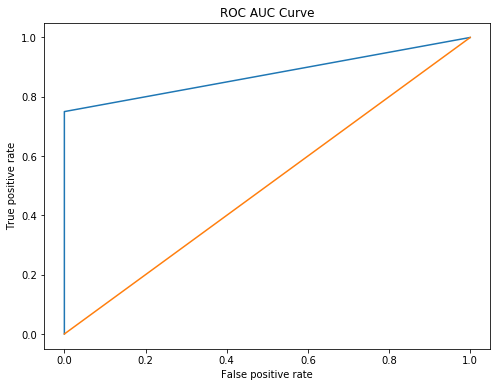

In [113]:
# TESTING DATASET ON BEST L
nrows = 480

t = time.time()
test_model = []
test_dataframe = pd.DataFrame() 
for feat in testing_dataset:
    feat = feat.loc[:,feat.columns != '# Columns: time']

    # break the dataset
    new_pd = pd.DataFrame()
    chunk_size = int(nrows/best_l_l1)
    chunks = split_df(feat, nrows, chunk_size)
    for c in chunks:
        new_pd = pd.concat([new_pd,c.reset_index(drop = True)],axis = 1)

    # time-domain features
    tf_feat = new_pd.describe()[1:].transpose()
    test_dataframe = test_dataframe.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)

test_dataframe['is_bending'] = 0
test_dataframe.iloc[0:4]['is_bending'] = 1
test_dataframe.iloc[4:]['is_bending'] = 0    
features = test_dataframe.iloc[:,0:(test_dataframe.shape[1] - 1)]
target = test_dataframe.iloc[:,(test_dataframe.shape[1] - 1)]
print(test_dataframe.shape, features.shape, target.shape)
test_values = best_l1_model.predict(features)

confusion_matrix_5 = metrics.confusion_matrix(target,test_values)
print("========== Confusion Matrix ==========")
print(confusion_matrix_5)
fpr_5, tpr_5, _ = metrics.roc_curve(target,test_values)
auc_5 = metrics.roc_auc_score(target,test_values)
plt.figure(figsize=(8,6))
plt.plot(fpr_5, tpr_5, label='ROC curve (area = %0.2f)' % auc_5)
plt.plot([0,1],[0,1])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve")
print("Area under the curve :- ",auc_5)

#### Compare the L 1 -penalized with variable selection using p-values. Which one performs better? Which one is easier to implement?

### Q(f) Multi-class Classification (The Realistic Case)

#### Qf(i) Find the best l in the same way as you found it in 1(e)i to build an L 1 - penalized multinomial regression model to classify all activities in your training set. Report your test error. Research how confusion matrices and ROC curves are defined for multiclass classification and show them for this problem if possible.

In [132]:
grid = {"C":np.logspace(-4,4,7)}
C_multinom_values = []
cv_multinom_scores = []
multinom_models = []

for l, m in enumerate(models_normalized):
    m['activities'] = "NA"
    m.iloc[0:9]['activities'] = "bending"
    m.iloc[9:21]['activities'] = "cycling"
    m.iloc[21:33]['activities'] = "lying"
    m.iloc[33:45]['activities'] = "sitting"
    m.iloc[45:57]['activities'] = "standing"
    m.iloc[57:69]['activities'] = "walking"
    labelencoder = LabelEncoder()
    m['activities'] = labelencoder.fit_transform(m['activities'])
    m = m.drop(["is_bending"],axis=1)
    print(m.shape)
    
    features = m.iloc[:,0:(m.shape[1] - 1)]
    target = m.iloc[:,(m.shape[1] - 1)]
    print(features.shape, target.shape)
 
    multi_logreg = LogisticRegression(penalty = 'l1',multi_class = "multinomial", solver = "saga", random_state=4)
    logreg_cv = GridSearchCV(multi_logreg, grid, cv = StratifiedKFold(5))
    logreg_cv.fit(features,target)
    best_logreg_c = logreg_cv.best_estimator_.get_params()['C']
    C_multinom_values.append(best_logreg_c)
    print(l+1, best_logreg_c)
    
    logreg_refit = LogisticRegression(C = best_logreg_c, penalty = 'l1',multi_class = "multinomial", solver = "saga",random_state=4)
    logreg_refit.fit(features, target)
    multinom_models.append(logreg_refit)
    print(cross_val_score(logreg_refit, features, target, cv = StratifiedKFold(5)).mean())
    cv_multinom_scores.append(cross_val_score(logreg_refit, features, target, cv = StratifiedKFold(5)).mean())    

(69, 43)
(69, 42) (69,)
1 464.1588833612773
0.8999108734402851
(69, 85)
(69, 84) (69,)
2 464.1588833612773
0.8494652406417111
(69, 127)
(69, 126) (69,)
3 464.1588833612773
0.8597147950089126
(69, 169)
(69, 168) (69,)
4 464.1588833612773
0.8999108734402851
(69, 211)
(69, 210) (69,)
5 464.1588833612773
0.8881461675579322
(69, 253)
(69, 252) (69,)
6 464.1588833612773
0.9014260249554367
(69, 295)
(69, 294) (69,)
7 464.1588833612773
0.8714795008912656
(69, 337)
(69, 336) (69,)
8 464.1588833612773
0.8881461675579322
(69, 379)
(69, 378) (69,)
9 464.1588833612773
0.8832442067736185
(69, 421)
(69, 420) (69,)
10 464.1588833612773
0.8763814616755793
(69, 463)
(69, 462) (69,)
11 464.1588833612773
0.8881461675579322
(69, 505)
(69, 504) (69,)
12 10000.0
0.8999108734402851
(69, 547)
(69, 546) (69,)
13 21.54434690031882
0.8597147950089126
(69, 589)
(69, 588) (69,)
14 21.54434690031882
0.8729946524064169
(69, 631)
(69, 630) (69,)
15 21.54434690031882
0.8714795008912656
(69, 673)
(69, 672) (69,)
16 21.5

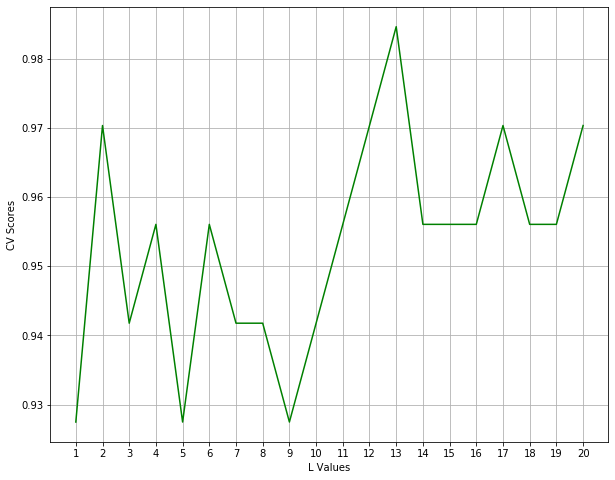

In [133]:
# Plot of CV Scores
plt.figure(figsize=(10,8))
plt.plot(list(split_range),cv_scores,color='green',label='CV scores')
plt.xticks(np.arange(1,21))
plt.xlabel("L Values")
plt.ylabel("CV Scores")
plt.grid()

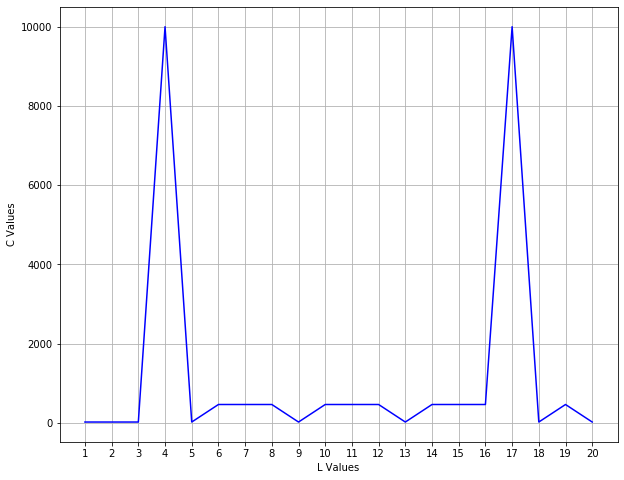

In [134]:
# Plot of C Values
plt.figure(figsize=(10,8))
plt.plot(list(split_range),C_values,color='blue',label='CV scores')
plt.xticks(np.arange(1,21))
plt.xlabel("L Values")
plt.ylabel("C Values")
plt.grid()

In [143]:
best_l_multinom = cv_multinom_scores.index(max(cv_multinom_scores))+1
print(best_l_multinom, C_multinom_values[best_l_multinom-1], cv_multinom_scores[best_l_multinom-1])
best_l1_multinom_model = multinom_models[best_l_multinom-1]

best_multinom_model = models_normalized[best_l_multinom - 1]
best_multinom_model = best_multinom_model.drop(["is_bending"],axis=1)
best_multinom_model['activities'] = "NA"
best_multinom_model.iloc[0:9]['activities'] = "bending"
best_multinom_model.iloc[9:21]['activities'] = "cycling"
best_multinom_model.iloc[21:33]['activities'] = "lying"
best_multinom_model.iloc[33:45]['activities'] = "sitting"
best_multinom_model.iloc[45:57]['activities'] = "standing"
best_multinom_model.iloc[57:69]['activities'] = "walking"
labelencoder = LabelEncoder()
best_multinom_model['activities'] = labelencoder.fit_transform(best_multinom_model['activities'])
print(best_multinom_model.shape)

features = best_multinom_model.iloc[:,0:(best_multinom_model.shape[1] - 1)]
target = best_multinom_model.iloc[:,(best_multinom_model.shape[1] - 1)]
print(features.shape, target.shape)

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.3, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
y_pred = best_l1_multinom_model.predict(X_test)

confusion_matrix_6 = metrics.confusion_matrix(y_test, y_pred)
print("========== Confusion Matrix ==========")
print(confusion_matrix_6)

lb = LabelBinarizer()
lb.fit(y_test)
target = lb.transform(y_test)
y_pred = lb.transform(y_pred)
metrics.roc_auc_score(target, y_pred)

6 464.1588833612773 0.9014260249554367
(69, 253)
(69, 252) (69,)
(48, 252) (21, 252) (48,) (21,)
========== Confusion Matrix ==========
[[3 0 0 0 0 0]
 [0 5 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 3 0 0]
 [0 0 0 0 4 0]
 [0 0 0 0 0 3]]


1.0

In [137]:
# TEST MULTINOMIAL MODEL
nrows = 480

t = time.time()
test_dataframe_m = pd.DataFrame() 
for feat in testing_dataset:
    feat = feat.loc[:,feat.columns != '# Columns: time']

    # break the dataset
    new_pd = pd.DataFrame()
    chunk_size = int(nrows/best_l_multinom)
    chunks = split_df(feat, nrows, chunk_size)
    for c in chunks:
        new_pd = pd.concat([new_pd,c.reset_index(drop = True)],axis = 1)

    # time-domain features
    tf_feat = new_pd.describe()[1:].transpose()
    test_dataframe_m = test_dataframe_m.append(pd.Series(tf_feat.values.flatten()),ignore_index = True)
print(test_dataframe_m.shape)
test_dataframe_m['activities'] = "NA"
#test_dataframe_m = test_dataframe_m.drop(["is_bending"],axis=1)
test_dataframe_m.iloc[0:4]['activities'] = "bending"
test_dataframe_m.iloc[4:7]['activities'] = "cycling"
test_dataframe_m.iloc[7:10]['activities'] = "lying"
test_dataframe_m.iloc[10:13]['activities'] = "sitting"
test_dataframe_m.iloc[13:16]['activities'] = "standing"
test_dataframe_m.iloc[16:19]['activities'] = "walking"
labelencoder = LabelEncoder()
test_dataframe_m['activities'] = labelencoder.fit_transform(test_dataframe_m['activities'])
print(test_dataframe_m.shape)


(19, 252)
(19, 253)


In [141]:
features = test_dataframe_m.iloc[:,0:(test_dataframe_m.shape[1] - 1)]
target = test_dataframe_m.iloc[:,(test_dataframe_m.shape[1] - 1)]
print(test_dataframe_m.shape, features.shape, target.shape)
test_values = best_l1_multinom_model.predict(features)

confusion_matrix_7 = metrics.confusion_matrix(target,test_values)
print("========== Confusion Matrix ==========")
print(confusion_matrix_7)


lb = LabelBinarizer()
lb.fit(target)
target = lb.transform(target)
test_values = lb.transform(test_values)
metrics.roc_auc_score(target, test_values)

(19, 253) (19, 252) (19,)
========== Confusion Matrix ==========
[[3 1 0 0 0 0]
 [0 3 0 0 0 0]
 [0 0 3 0 0 0]
 [0 0 0 2 1 0]
 [0 0 0 2 1 0]
 [0 0 0 0 0 3]]


0.875

#### Q1(f)(ii) Repeat 1(f)i using a Naı̈ve Bayes’ classifier. Use both Gaussian and Multinomial priors and compare the results.

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

gaussian_clf = GaussianNB()
multinomial_clf = MultinomialNB()
